# 📊 Netflix Data Analysis Project

## 📌 Introduction

This project analyzes a Netflix dataset to explore content distribution, trends over time, and audience preferences.  
The dataset includes information such as title, type, country, release year, and genres.

### Import Libraries & read data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("netflix1.csv")

In [2]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


## 🔍 Data Understanding

We explore the dataset structure, data types, and check for missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


## 🧹 Data Cleaning

Steps performed:
- Removed duplicates  
- Standardized column names  
- Converted date column  
- Cleaned text data  
- Extracted duration values

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop_duplicates(inplace=True)

df.columns = df.columns.str.strip().str.lower()
df.columns = df.columns.str.replace(" ", "_")

In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [8]:
df['duration_number'] = df['duration'].str.extract('(\d+)')
df['duration_number'] = df['duration_number'].astype(float)

In [9]:
df['country'] = df['country'].str.strip()
df['title'] = df['title'].str.strip()

In [10]:
df.to_csv("cleaned_netflix.csv", index=False)

## 📊 Data Analysis

In [12]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_number
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90.0
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1.0
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8790 non-null   object        
 1   type             8790 non-null   object        
 2   title            8790 non-null   object        
 3   director         8790 non-null   object        
 4   country          8790 non-null   object        
 5   date_added       8790 non-null   datetime64[ns]
 6   release_year     8790 non-null   int64         
 7   rating           8790 non-null   object        
 8   duration         8790 non-null   object        
 9   listed_in        8790 non-null   object        
 10  duration_number  8790 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(8)
memory usage: 755.5+ KB


## Movies vs TV Shows

In [14]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

### 🎯 Insight:
Movies are more dominant than TV Shows on Netflix.

In [15]:
df['country'].value_counts().head(10)

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

### 🎯 Insight:
The United States is the leading country in Netflix content production.

In [16]:
genres = df['listed_in'].str.split(',', expand=True).stack()
genres = genres.str.strip()

genres.value_counts().head(10)

International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

### 🎯 Insight:
Drama and international Moviess are the most common.

In [17]:
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

### 🎯 Insight:
Content production increased significantly after 2015.

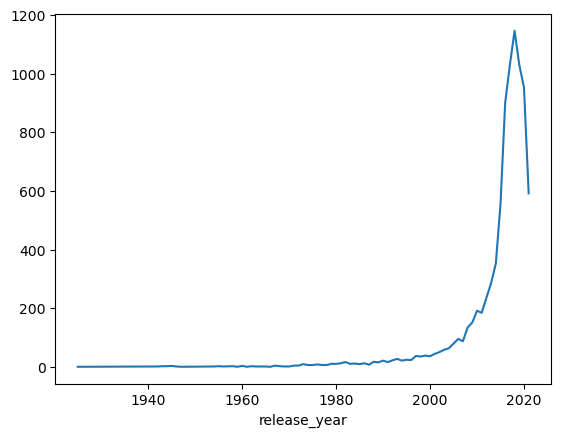

In [18]:
import matplotlib.pyplot as plt

df['release_year'].value_counts().sort_index().plot()
plt.show()

In [19]:
df['date_added'].dt.year.value_counts()

date_added
2019    2016
2020    1879
2018    1648
2021    1498
2017    1185
2016     426
2015      82
2014      24
2011      13
2013      11
2012       3
2009       2
2008       2
2010       1
Name: count, dtype: int64

In [20]:
df['year_added'] = df['date_added'].dt.year

## 📈 Data Visualization

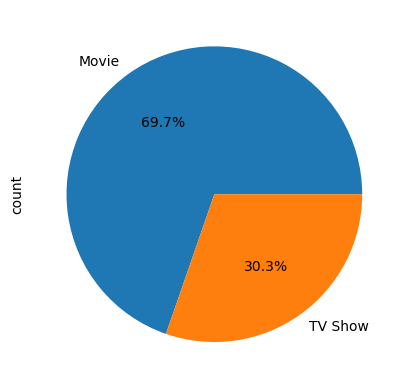

In [27]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

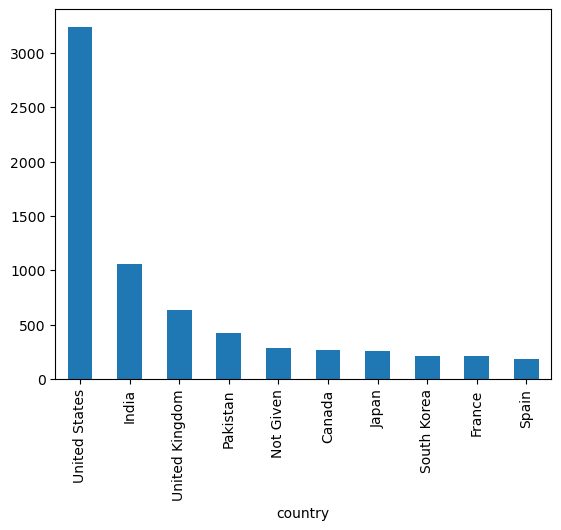

In [28]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.show()

## ✅ Conclusion

Netflix focuses more on movies than TV shows and has significantly increased its content production in recent years.  
The platform offers diverse content targeting a global audience.